# House Price Prediction — Regression Analysis

Bohdan Pavlyshenko (https://www.linkedin.com/in/bpavlyshenko) 

**Dataset:** [Kaggle — House Prices: Advanced Regression Techniques](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques)

---

## Overview

This notebook demonstrates supervised regression for predicting residential property sale
prices using the Ames, Iowa housing dataset. With 79 explanatory features covering lot
dimensions, building quality, square footage, garage attributes, and sale conditions, the
dataset is ideal for exploring feature engineering, missing-value handling, and the comparison
of gradient boosting algorithms.

**Learning objectives:**
- Perform comprehensive exploratory data analysis on a real estate dataset
- Handle missing values and encode categorical features robustly
- Train and compare six regression models: Linear, Ridge, Lasso, Random Forest, XGBoost, LightGBM
- Evaluate models with MAE, RMSE, R², and MAPE
- Interpret predictions with SHAP values and residual diagnostics
- Build a stacking ensemble from diverse base learners


In [35]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_predict
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    root_mean_squared_error,
)
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import shap

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Libraries loaded successfully.")


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.Libraries loaded successfully.



## 1. Helper Functions

Utility functions used throughout the notebook for evaluation and visualisation.
Centralising these avoids code duplication and makes the notebook easier to maintain.


In [36]:
def compute_regression_metrics(y_true, y_pred, model_name="Model"):
    """Compute and display standard regression metrics.

    Args:
        y_true (array-like): Ground-truth target values.
        y_pred (array-like): Model predictions.
        model_name (str): Label for printed output. Defaults to "Model".

    Returns:
        dict: Keys 'mae', 'rmse', 'r2', 'mape'.

    Note:
        MAPE is computed only on non-zero actuals to avoid division by zero.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    print(
        f"{model_name:35s} | MAE={mae:.4f}  RMSE={rmse:.4f}  "
        f"R²={r2:.4f}  MAPE={mape:.2f}%"
    )
    return {"mae": mae, "rmse": rmse, "r2": r2, "mape": mape}


def plot_actual_vs_predicted(y_true, y_pred, title="Actual vs Predicted"):
    """Scatter plot of actual vs predicted values with identity line.

    Args:
        y_true (array-like): Ground-truth values.
        y_pred (array-like): Predicted values.
        title (str): Plot title. Defaults to "Actual vs Predicted".
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(y_true, y_pred, alpha=0.35, edgecolors="none", s=20)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, "r--", linewidth=2, label="Perfect prediction")
    ax.set_xlabel("Actual (log scale)", fontsize=12)
    ax.set_ylabel("Predicted (log scale)", fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_residuals(y_true, y_pred, title="Residual Analysis"):
    """Residuals vs fitted values and residual histogram side-by-side.

    Args:
        y_true (array-like): Ground-truth values.
        y_pred (array-like): Predicted values.
        title (str): Figure-level title. Defaults to "Residual Analysis".
    """
    residuals = np.asarray(y_true, dtype=float) - np.asarray(y_pred, dtype=float)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].scatter(y_pred, residuals, alpha=0.35, edgecolors="none", s=15)
    axes[0].axhline(0, color="red", linestyle="--")
    axes[0].set_xlabel("Fitted Values")
    axes[0].set_ylabel("Residuals")
    axes[0].set_title("Residuals vs Fitted")

    sns.histplot(residuals, kde=True, ax=axes[1], bins=40)
    axes[1].set_xlabel("Residual")
    axes[1].set_title("Residual Distribution")

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


## 2. Data Loading and Initial Overview

The Ames housing dataset contains **1,460** records of residential properties sold in Ames,
Iowa between 2006 and 2010. Each record has **79 features** covering lot characteristics,
building type, quality ratings, square footage, and garage attributes.


In [37]:
df = pd.read_csv("data/house_price.csv")
print(f"Shape: {df.shape}")
print(f"\nData types:\n{df.dtypes.value_counts()}")


Shape: (1460, 81)

Data types:
str        43
int64      35
float64     3
Name: count, dtype: int64


In [38]:
df.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 3. Exploratory Data Analysis

### 3.1 Target Variable — Sale Price

We apply a `log1p` transformation to the target to reduce right-skewness and make
the distribution approximately normal. This transformation also means that RMSE on
the log scale roughly corresponds to the mean percentage error in the original scale.


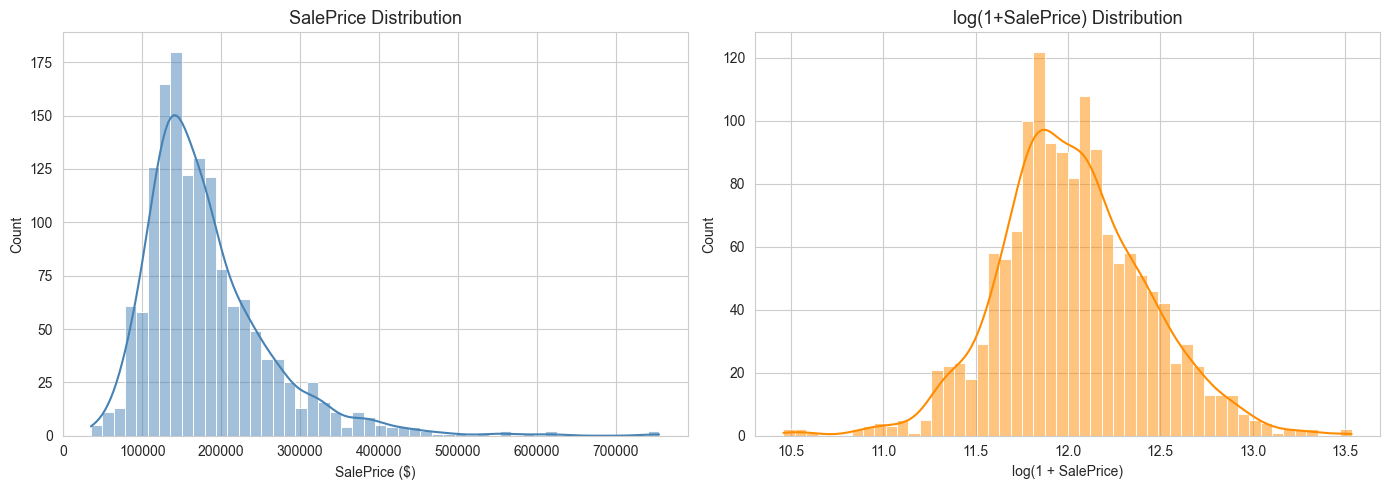

In [39]:
df["logSalePrice"] = np.log1p(df["SalePrice"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["SalePrice"], ax=axes[0], kde=True, bins=50, color="steelblue")
axes[0].set_title("SalePrice Distribution", fontsize=13)
axes[0].set_xlabel("SalePrice ($)")

sns.histplot(df["logSalePrice"], ax=axes[1], kde=True, bins=50, color="darkorange")
axes[1].set_title("log(1+SalePrice) Distribution", fontsize=13)
axes[1].set_xlabel("log(1 + SalePrice)")

plt.tight_layout()
plt.show()


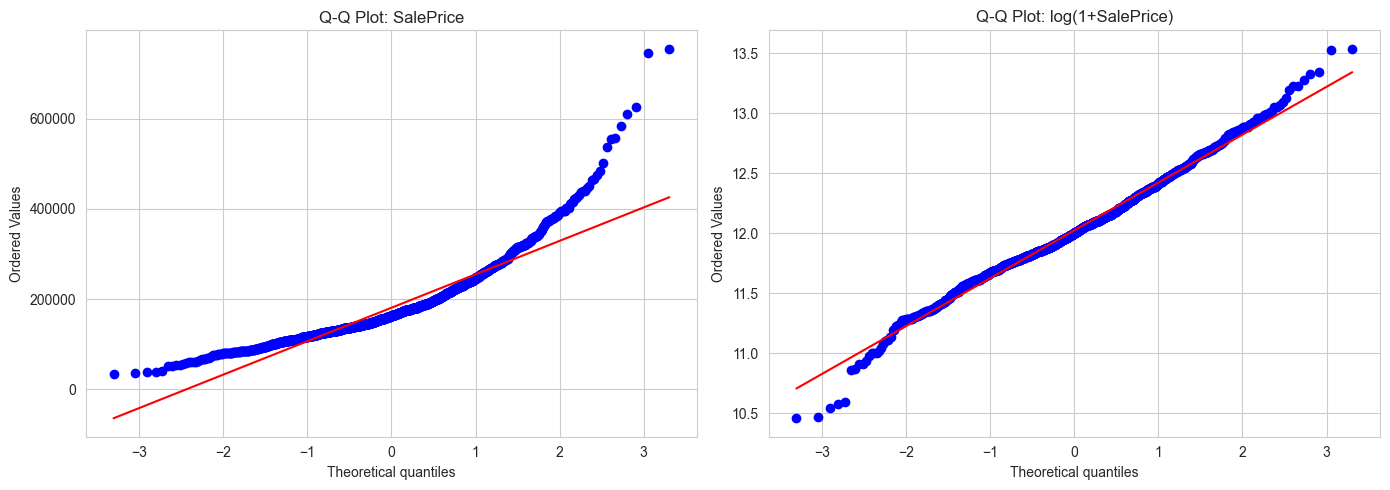

In [40]:
# Q-Q plots assess normality — log-transformed target is much closer to normal
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
stats.probplot(df["SalePrice"], dist="norm", plot=axes[0])
axes[0].set_title("Q-Q Plot: SalePrice")
stats.probplot(df["logSalePrice"], dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot: log(1+SalePrice)")
plt.tight_layout()
plt.show()


### 3.2 Missing Value Analysis

Understanding missing data patterns informs preprocessing decisions (imputation vs. dropping).
Features with high missingness often indicate structural absence (e.g., `PoolQC` is mostly
missing because most properties have no pool).


In [41]:
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)
missing_pct = (missing_counts / len(df) * 100).round(2)
missing_df = pd.DataFrame({"count": missing_counts, "pct (%)": missing_pct})
print(f"Features with missing values: {len(missing_df)}")
display(missing_df.head(25))


Features with missing values: 19


,count,pct (%)
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


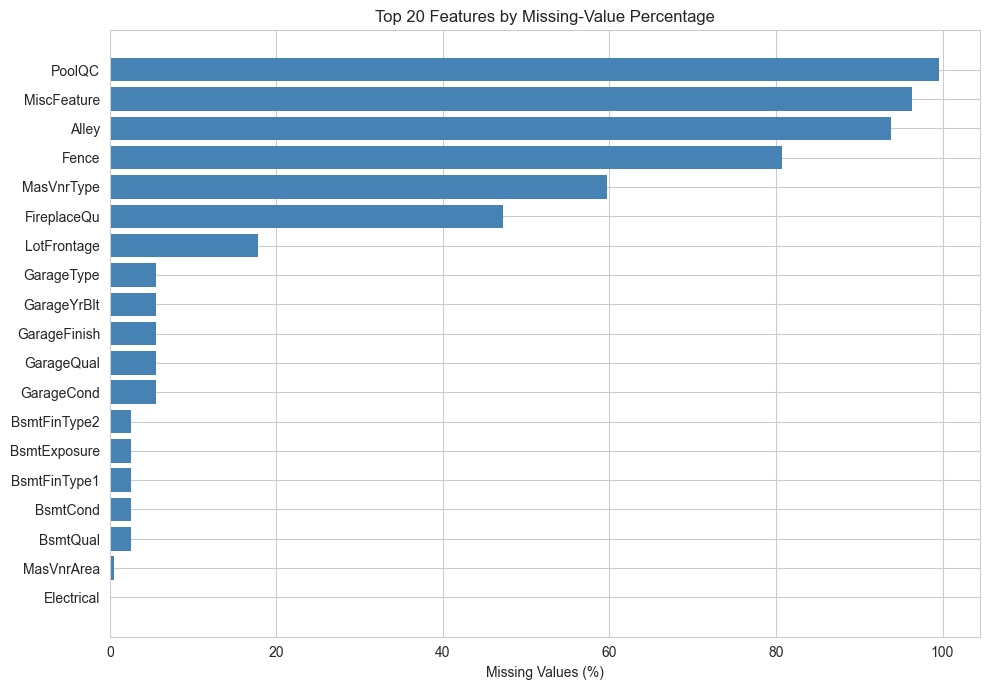

In [42]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(
    missing_df.index[:20],
    missing_df["pct (%)"][:20],
    color="steelblue",
    edgecolor="none",
)
ax.set_xlabel("Missing Values (%)")
ax.set_title("Top 20 Features by Missing-Value Percentage")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### 3.3 Numeric vs Categorical Feature Split

We separate numeric and categorical features for appropriate preprocessing.


In [43]:
exclude_cols = ["Id", "SalePrice", "logSalePrice"]
num_features = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c not in exclude_cols
]
cat_features = list(df.select_dtypes(include=["object"]).columns)

print(f"Numeric features : {len(num_features)}")
print(f"Categorical features : {len(cat_features)}")


Numeric features : 36
Categorical features : 43


In [44]:
df.describe()[num_features[:12]]


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000


### 3.4 Correlation with Target Variable


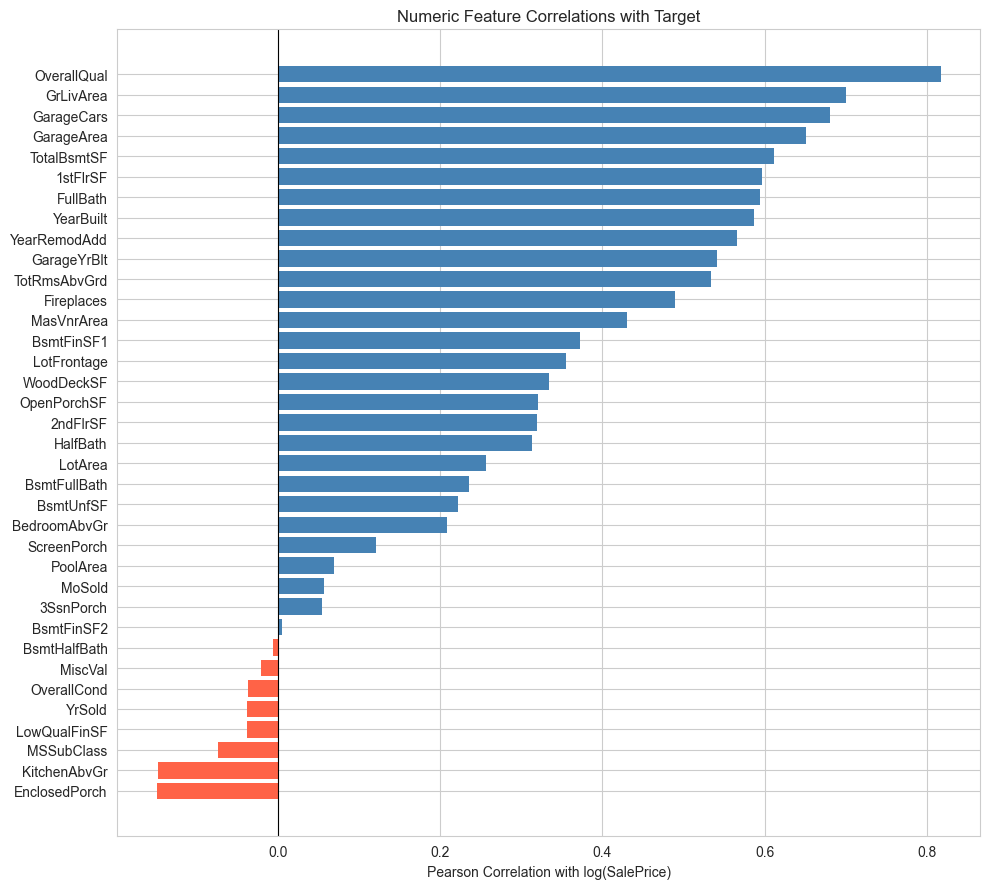

In [45]:
target = "logSalePrice"

corr_target = (
    df[num_features + [target]]
    .corr()[target]
    .drop(target)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 9))
colors = ["steelblue" if v > 0 else "tomato" for v in corr_target.values]
ax.barh(corr_target.index, corr_target.values, color=colors, edgecolor="none")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson Correlation with log(SalePrice)")
ax.set_title("Numeric Feature Correlations with Target")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


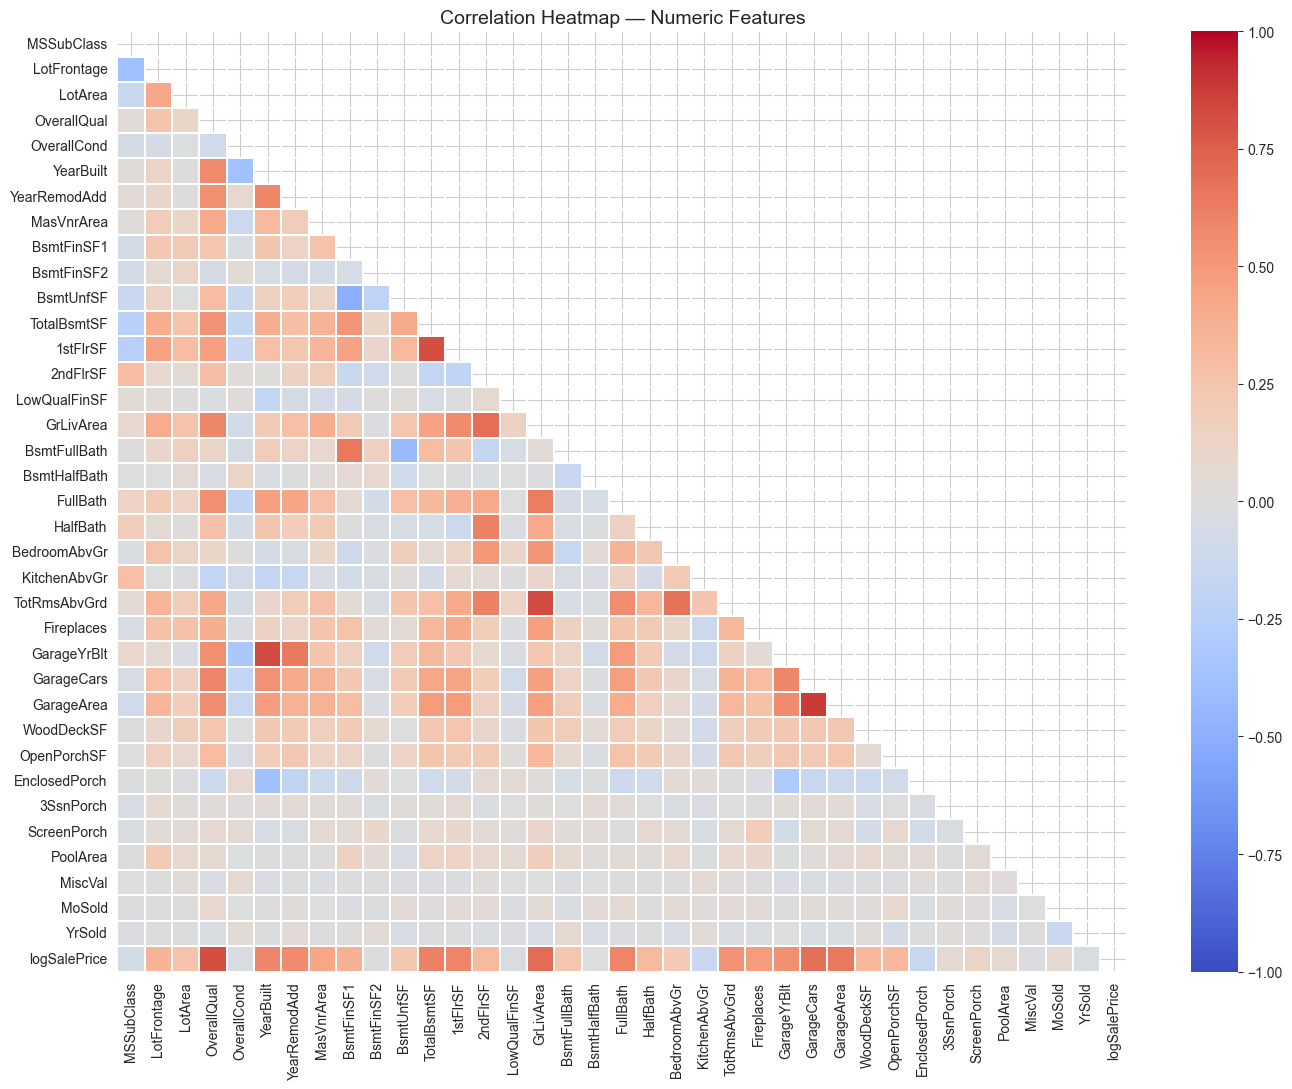

In [46]:
# Correlation heatmap (lower triangle only)
corr_matrix = df[num_features + [target]].corr()
fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, cmap="coolwarm", vmin=-1, vmax=1,
    linewidths=0.3, ax=ax, annot=False
)
ax.set_title("Correlation Heatmap — Numeric Features", fontsize=14)
plt.tight_layout()
plt.show()


### 3.5 Key Feature Relationships


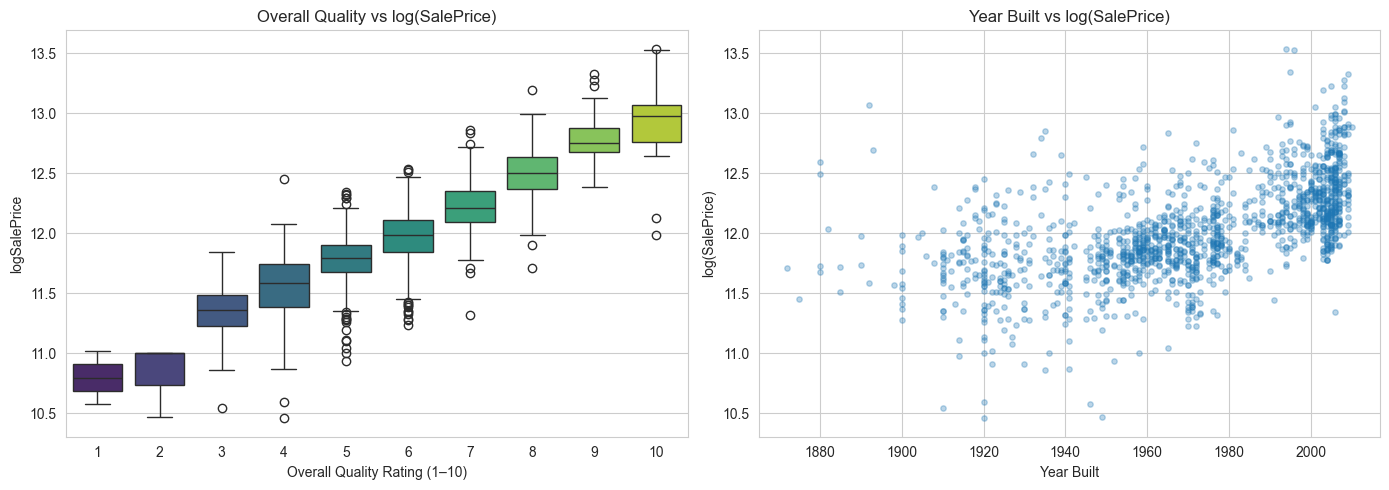

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x="OverallQual", y=target, data=df, ax=axes[0], palette="viridis")
axes[0].set_title("Overall Quality vs log(SalePrice)")
axes[0].set_xlabel("Overall Quality Rating (1–10)")

axes[1].scatter(df["YearBuilt"], df[target], alpha=0.3, s=15)
axes[1].set_xlabel("Year Built")
axes[1].set_ylabel("log(SalePrice)")
axes[1].set_title("Year Built vs log(SalePrice)")

plt.tight_layout()
plt.show()


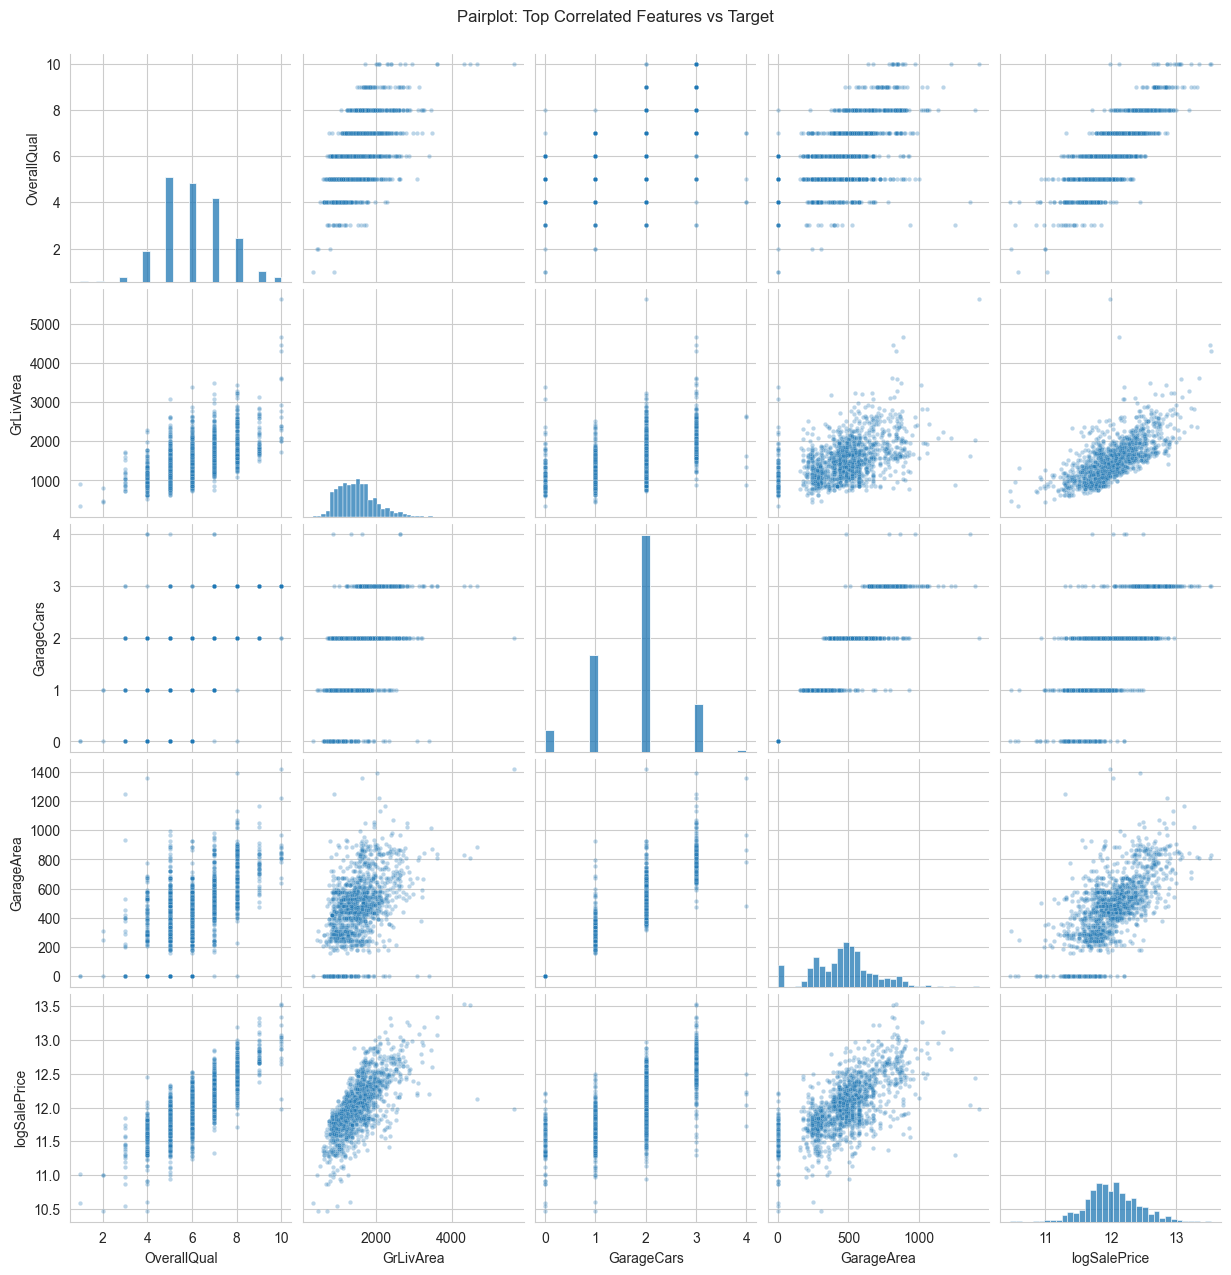

In [48]:
# Pairplot for top correlated numeric features
top_num = corr_target.abs().head(4).index.tolist()
sns.pairplot(
    df[top_num + [target]].dropna(),
    height=2.5,
    plot_kws={"alpha": 0.3, "s": 10},
)
plt.suptitle("Pairplot: Top Correlated Features vs Target", y=1.02)
plt.show()


### 3.6 Outlier Inspection

Large properties sold at unusually low prices (extreme outliers) can distort regression
models. We visualise `GrLivArea` and `TotalBsmtSF` as they have the highest correlations
with the target.


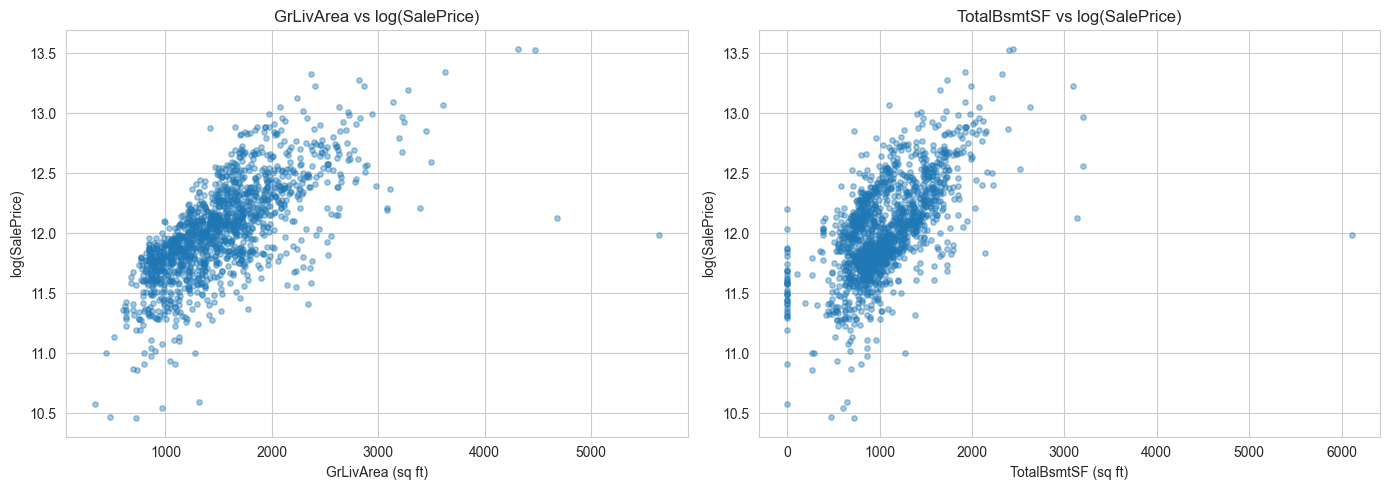

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df["GrLivArea"], df[target], alpha=0.4, s=15)
axes[0].set_xlabel("GrLivArea (sq ft)")
axes[0].set_ylabel("log(SalePrice)")
axes[0].set_title("GrLivArea vs log(SalePrice)")

axes[1].scatter(df["TotalBsmtSF"], df[target], alpha=0.4, s=15)
axes[1].set_xlabel("TotalBsmtSF (sq ft)")
axes[1].set_ylabel("log(SalePrice)")
axes[1].set_title("TotalBsmtSF vs log(SalePrice)")

plt.tight_layout()
plt.show()


### 3.7 Feature Engineering

Domain knowledge lets us derive aggregate measures that capture more information than
individual columns alone. Engineered features consistently rank among the top predictors
in gradient-boosting models on this dataset.

| Feature | Formula | Rationale |
|---------|---------|----------|
| `TotalSF` | BsmtSF + 1stFlrSF + 2ndFlrSF | Total conditioned indoor area |
| `HouseAge` | YrSold − YearBuilt | Age of the house at sale |
| `RemodAge` | YrSold − YearRemodAdd | Years since last remodel |
| `TotalBaths` | FullBath + 0.5×HalfBath + BsmtFullBath + 0.5×BsmtHalfBath | Weighted bathroom count |
| `HasGarage` | GarageArea > 0 | Binary: garage present |
| `HasPool` | PoolArea > 0 | Binary: pool present |
| `Has2ndFloor` | 2ndFlrSF > 0 | Binary: second floor present |


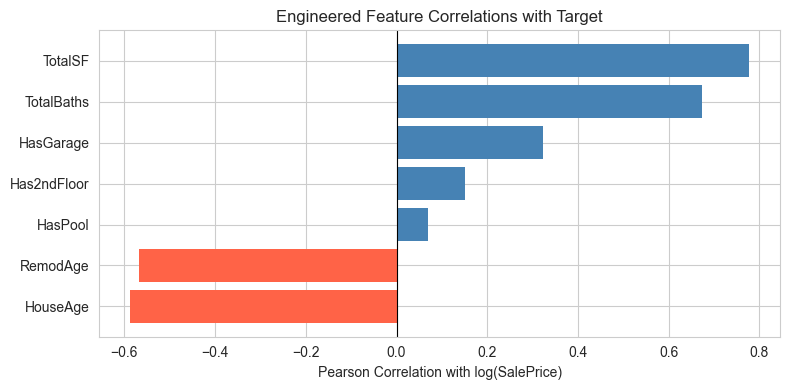

Numeric feature count after engineering: 43


In [50]:
# Total conditioned square footage
df["TotalSF"] = (
    df["TotalBsmtSF"].fillna(0)
    + df["1stFlrSF"].fillna(0)
    + df["2ndFlrSF"].fillna(0)
)

# Age-based features
df["HouseAge"]  = df["YrSold"] - df["YearBuilt"]
df["RemodAge"]  = df["YrSold"] - df["YearRemodAdd"]

# Bathroom count (full = 1, half = 0.5)
df["TotalBaths"] = (
    df["FullBath"].fillna(0)
    + 0.5 * df["HalfBath"].fillna(0)
    + df["BsmtFullBath"].fillna(0)
    + 0.5 * df["BsmtHalfBath"].fillna(0)
)

# Binary presence flags
df["HasGarage"]   = (df["GarageArea"].fillna(0) > 0).astype(int)
df["HasPool"]     = (df["PoolArea"].fillna(0) > 0).astype(int)
df["Has2ndFloor"] = (df["2ndFlrSF"].fillna(0) > 0).astype(int)

new_features = ["TotalSF", "HouseAge", "RemodAge", "TotalBaths",
                "HasGarage", "HasPool", "Has2ndFloor"]
num_features.extend(new_features)

# Visualise correlation of engineered features with target
new_corr = (
    df[new_features + [target]]
    .corr()[target]
    .drop(target)
    .sort_values(ascending=False)
)
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["steelblue" if v > 0 else "tomato" for v in new_corr.values]
ax.barh(new_corr.index, new_corr.values, color=colors, edgecolor="none")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson Correlation with log(SalePrice)")
ax.set_title("Engineered Feature Correlations with Target")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"Numeric feature count after engineering: {len(num_features)}")

## 4. Data Preprocessing

### 4.1 Categorical Feature Encoding

`LabelEncoder` converts each categorical feature to an integer representation. Tree-based
models handle this well because they learn optimal splits; linear models require one-hot
encoding (handled by StandardScaler downstream).

We fill NaN values with the string `"Missing"` before encoding so that missing values
become a valid category rather than causing errors.


In [51]:
cat_features_enc = []
for feat in cat_features:
    enc_name = feat + "_enc"
    cat_features_enc.append(enc_name)
    le = LabelEncoder()
    df[enc_name] = le.fit_transform(df[feat].fillna("Missing").astype(str))

print(f"Encoded {len(cat_features_enc)} categorical features.")
print("Sample encoded columns:", cat_features_enc[:5])


Encoded 43 categorical features.
Sample encoded columns: ['MSZoning_enc', 'Street_enc', 'Alley_enc', 'LotShape_enc', 'LandContour_enc']


### 4.2 Train / Test Split

We use a stratified 70/30 random split with a fixed `random_state` for reproducibility.


In [52]:
from sklearn.impute import SimpleImputer

features = num_features + cat_features_enc

train_df, test_df = train_test_split(df, test_size=0.3, random_state=RANDOM_STATE)

X_train = train_df[features].values
X_test  = test_df[features].values
y_train = train_df[target].values
y_test  = test_df[target].values

# Impute remaining NaN in numeric features using training-set medians
imputer = SimpleImputer(strategy="median")
X_train = imputer.fit_transform(X_train)
X_test  = imputer.transform(X_test)

print(f"Training set :  {X_train.shape}  NaN: {int(np.isnan(X_train).sum())}")
print(f"Test set     :  {X_test.shape}   NaN: {int(np.isnan(X_test).sum())}")


Training set :  (1022, 86)  NaN: 0
Test set     :  (438, 86)   NaN: 0


## 5. Model Development

We compare six approaches in increasing complexity:

| # | Model | Regularisation | Notes |
|---|-------|---------------|-------|
| 1 | Linear Regression | None | Baseline parametric |
| 2 | Ridge (L2) | L2 | Shrinks all coefficients |
| 3 | Lasso (L1) | L1 | Sparse; automatic feature selection |
| 4 | Random Forest | None | Bagging ensemble of trees |
| 5 | XGBoost | L1 + L2 | Sequential gradient boosting |
| 6 | LightGBM | L1 + L2 | Fast histogram-based boosting |

All models use the same 70/30 split for fair comparison.

### 5.1 Baseline — Linear Regression

Linear regression provides an interpretable lower bound. We standardise features because
linear models are sensitive to feature scale.


In [53]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_sc, y_train)

results = {}
results["Linear Regression"] = {
    "train": compute_regression_metrics(y_train, lr.predict(X_train_sc), "Linear Regression  (train)"),
    "test":  compute_regression_metrics(y_test,  lr.predict(X_test_sc),  "Linear Regression  (test )"),
}


Linear Regression  (train)          | MAE=0.0824  RMSE=0.1200  R²=0.9071  MAPE=0.69%
Linear Regression  (test )          | MAE=0.0996  RMSE=0.1521  R²=0.8635  MAPE=0.84%


### 5.2 Ridge Regression (L2)

Ridge shrinks all coefficient magnitudes toward zero, reducing variance when many
correlated features are present — a common situation in housing data.


In [54]:
ridge = Ridge(alpha=10.0, random_state=RANDOM_STATE)
ridge.fit(X_train_sc, y_train)

results["Ridge"] = {
    "train": compute_regression_metrics(y_train, ridge.predict(X_train_sc), "Ridge              (train)"),
    "test":  compute_regression_metrics(y_test,  ridge.predict(X_test_sc),  "Ridge              (test )"),
}


Ridge              (train)          | MAE=0.0854  RMSE=0.1241  R²=0.9007  MAPE=0.71%
Ridge              (test )          | MAE=0.1019  RMSE=0.1481  R²=0.8707  MAPE=0.86%


### 5.3 Lasso Regression (L1)

Lasso drives less informative coefficients exactly to zero, performing implicit feature
selection. This is valuable because many of the 79 features are weakly correlated with
price.


In [55]:
lasso = Lasso(alpha=0.001, max_iter=20000, random_state=RANDOM_STATE)
lasso.fit(X_train_sc, y_train)

n_zero = np.sum(np.abs(lasso.coef_) < 1e-6)
print(f"Lasso zeroed {n_zero}/{len(lasso.coef_)} coefficients ({n_zero/len(lasso.coef_)*100:.1f}%)")

results["Lasso"] = {
    "train": compute_regression_metrics(y_train, lasso.predict(X_train_sc), "Lasso              (train)"),
    "test":  compute_regression_metrics(y_test,  lasso.predict(X_test_sc),  "Lasso              (test )"),
}


Lasso zeroed 13/86 coefficients (15.1%)
Lasso              (train)          | MAE=0.0838  RMSE=0.1218  R²=0.9044  MAPE=0.70%
Lasso              (test )          | MAE=0.0996  RMSE=0.1469  R²=0.8727  MAPE=0.84%


### 5.4 Random Forest

Each tree in a Random Forest is trained on a bootstrap sample using a random feature
subset, reducing variance via averaging. It naturally captures non-linear interactions
and does not require feature scaling.


In [56]:
rf = RandomForestRegressor(
    n_estimators=200, max_depth=None,
    min_samples_leaf=2, n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf.fit(X_train, y_train)

results["Random Forest"] = {
    "train": compute_regression_metrics(y_train, rf.predict(X_train), "Random Forest      (train)"),
    "test":  compute_regression_metrics(y_test,  rf.predict(X_test),  "Random Forest      (test )"),
}


Random Forest      (train)          | MAE=0.0405  RMSE=0.0646  R²=0.9731  MAPE=0.34%
Random Forest      (test )          | MAE=0.0886  RMSE=0.1329  R²=0.8959  MAPE=0.74%


Random Forest      (test )          | MAE=0.0886  RMSE=0.1329  R²=0.8959  MAPE=0.74%


### 5.5 XGBoost

XGBoost builds trees sequentially where each tree corrects the residuals of the previous
ones. It includes built-in L1/L2 regularisation and handles missing values natively via a
learned default direction at each split.


In [57]:
xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    early_stopping_rounds=50,
    eval_metric="rmse",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100,
)

results["XGBoost"] = {
    "train": compute_regression_metrics(y_train, xgb_model.predict(X_train), "XGBoost            (train)"),
    "test":  compute_regression_metrics(y_test,  xgb_model.predict(X_test),  "XGBoost            (test )"),
}


[0]	validation_0-rmse:0.37834	validation_1-rmse:0.39691
[100]	validation_0-rmse:0.06057	validation_1-rmse:0.13377
[200]	validation_0-rmse:0.04021	validation_1-rmse:0.13119
[261]	validation_0-rmse:0.03223	validation_1-rmse:0.13134
XGBoost            (train)          | MAE=0.0277  RMSE=0.0383  R²=0.9905  MAPE=0.23%
XGBoost            (test )          | MAE=0.0851  RMSE=0.1311  R²=0.8987  MAPE=0.71%


[100]	validation_0-rmse:0.06057	validation_1-rmse:0.13377


[200]	validation_0-rmse:0.04021	validation_1-rmse:0.13119


[261]	validation_0-rmse:0.03223	validation_1-rmse:0.13134


XGBoost            (train)          | MAE=0.0277  RMSE=0.0383  R²=0.9905  MAPE=0.23%
XGBoost            (test )          | MAE=0.0851  RMSE=0.1311  R²=0.8987  MAPE=0.71%


### 5.6 LightGBM with 5-Fold Cross-Validation

LightGBM uses histogram-based splits that are faster and more memory-efficient than
XGBoost. We additionally demonstrate k-fold cross-validation on the training set —
this provides a lower-variance performance estimate than a single validation split.


In [58]:
lgbm_params = {
    "boosting_type": "gbdt",
    "metric": "rmse",
    "objective": "regression",
    "n_jobs": -1,
    "seed": RANDOM_STATE,
    "num_leaves": 500,
    "max_depth": 5,
    "learning_rate": 0.01,
    "bagging_fraction": 0.5,
    "colsample_bytree": 0.5,
    "verbose": -1,
}
N_ESTIMATORS = 1000

lgbm_model = LGBMRegressor(**lgbm_params, n_estimators=N_ESTIMATORS)
lgbm_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
)

results["LightGBM"] = {
    "train": compute_regression_metrics(y_train, lgbm_model.predict(X_train), "LightGBM           (train)"),
    "test":  compute_regression_metrics(y_test,  lgbm_model.predict(X_test),  "LightGBM           (test )"),
}


LightGBM           (train)          | MAE=0.0453  RMSE=0.0676  R²=0.9705  MAPE=0.38%
LightGBM           (test )          | MAE=0.0809  RMSE=0.1232  R²=0.9106  MAPE=0.68%


In [59]:
# 5-fold cross-validation for unbiased estimate
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_preds = cross_val_predict(
    LGBMRegressor(**lgbm_params, n_estimators=N_ESTIMATORS),
    X_train, y_train, cv=kf, n_jobs=-1,
)
cv_rmse = root_mean_squared_error(y_train, cv_preds)
print(f"LightGBM 5-Fold CV RMSE (training set): {cv_rmse:.4f}")


LightGBM 5-Fold CV RMSE (training set): 0.1284


## 6. Model Comparison

### 6.1 Summary Table


In [60]:
comparison = []
for name, res in results.items():
    comparison.append({
        "Model":      name,
        "Train RMSE": round(res["train"]["rmse"], 4),
        "Test RMSE":  round(res["test"]["rmse"],  4),
        "Test R²":    round(res["test"]["r2"],    4),
        "Test MAE":   round(res["test"]["mae"],   4),
    })

comp_df = pd.DataFrame(comparison).sort_values("Test RMSE").reset_index(drop=True)
display(comp_df)


,Model,Train RMSE,Test RMSE,Test R²,Test MAE
0,LightGBM,0.0676,0.1232,0.9106,0.0809
1,XGBoost,0.0383,0.1311,0.8987,0.0851
2,Random Forest,0.0646,0.1329,0.8959,0.0886
3,Lasso,0.1218,0.1469,0.8727,0.0996
4,Ridge,0.1241,0.1481,0.8707,0.1019
5,Linear Regression,0.1200,0.1521,0.8635,0.0996


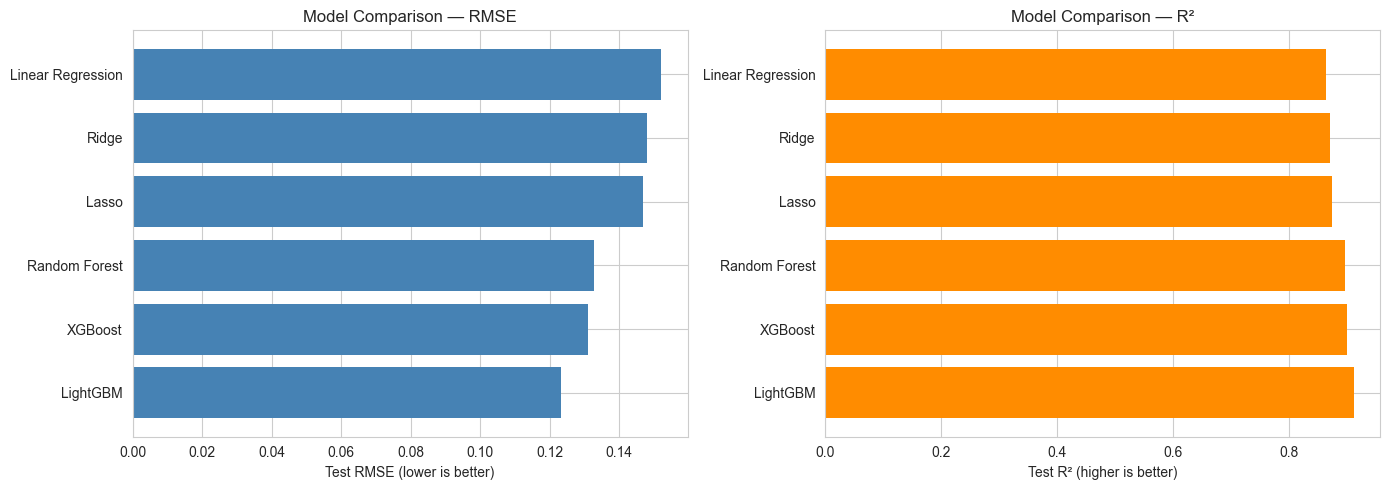

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(comp_df["Model"], comp_df["Test RMSE"], color="steelblue", edgecolor="none")
axes[0].set_xlabel("Test RMSE (lower is better)")
axes[0].set_title("Model Comparison — RMSE")

axes[1].barh(comp_df["Model"], comp_df["Test R²"], color="darkorange", edgecolor="none")
axes[1].set_xlabel("Test R² (higher is better)")
axes[1].set_title("Model Comparison — R²")

plt.tight_layout()
plt.show()


## 7. Model Diagnostics

### 7.1 Actual vs Predicted — Best Model (LightGBM)

Points near the dashed diagonal represent accurate predictions. Systematic deviations
indicate where the model struggles (typically extreme prices).


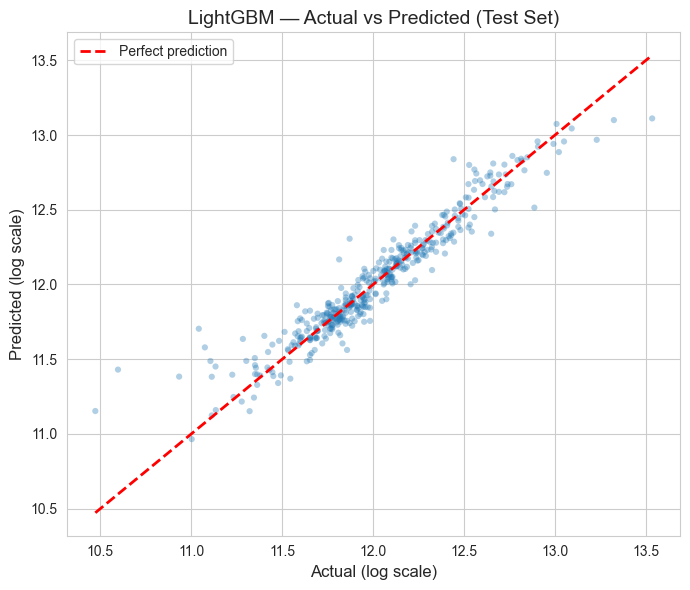

In [62]:
best_preds = lgbm_model.predict(X_test)
plot_actual_vs_predicted(y_test, best_preds, "LightGBM — Actual vs Predicted (Test Set)")


### 7.2 Residual Analysis

Residuals should be randomly distributed around zero. A fan-shaped pattern (larger
residuals at extreme prices) would indicate heteroskedasticity — a sign that the model
is less accurate for very expensive or very cheap properties.


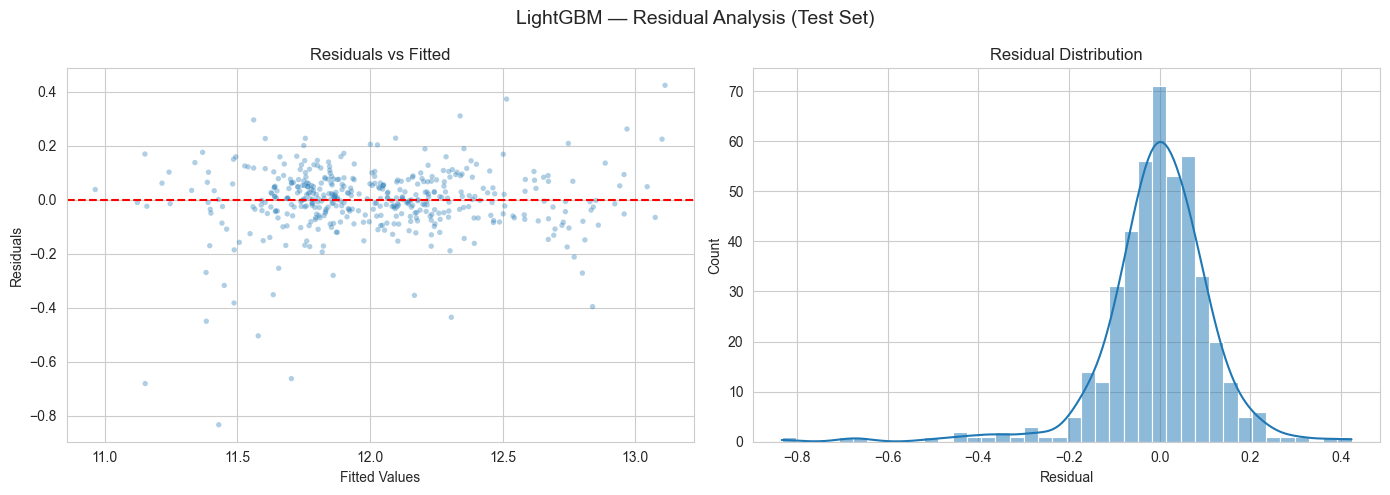

In [63]:
plot_residuals(y_test, best_preds, "LightGBM — Residual Analysis (Test Set)")


## 8. Feature Importance and Interpretability

### 8.1 LightGBM Feature Importance

Tree-based importance measures how often each feature is used for splitting (frequency)
and the resulting improvement in the training loss (gain).


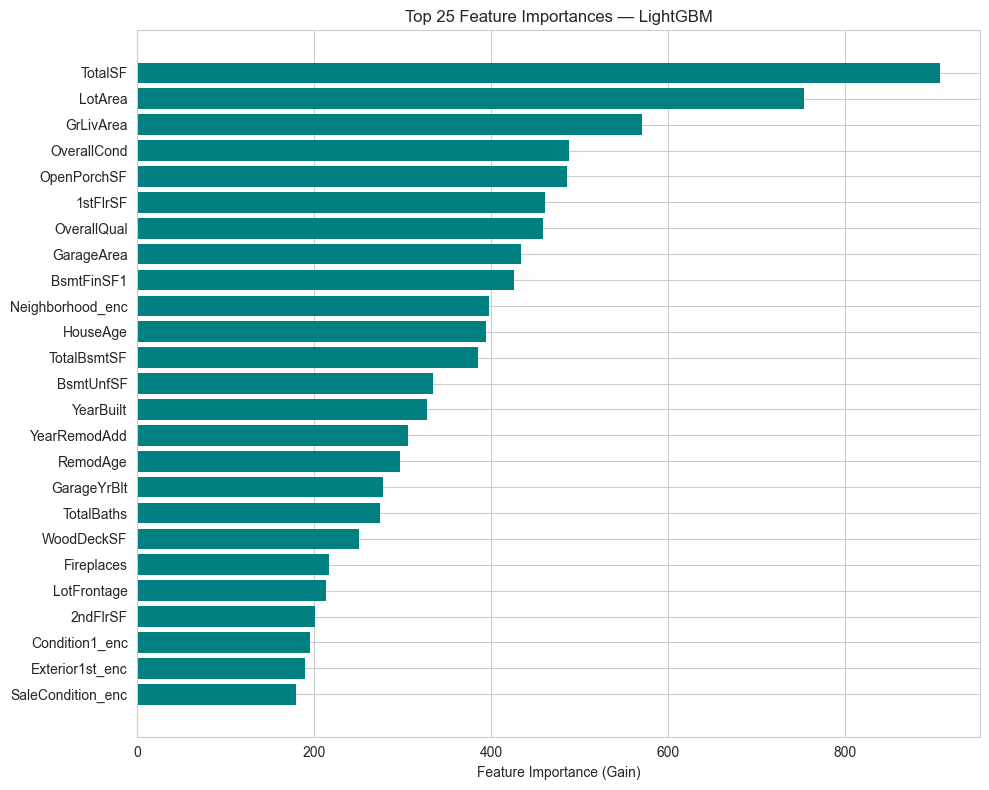

In [64]:
importance_df = (
    pd.DataFrame({"feature": features, "importance": lgbm_model.feature_importances_})
    .sort_values("importance", ascending=False)
    .head(25)
)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(importance_df["feature"], importance_df["importance"], color="teal", edgecolor="none")
ax.set_xlabel("Feature Importance (Gain)")
ax.set_title("Top 25 Feature Importances — LightGBM")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### 8.2 SHAP Values

SHAP (SHapley Additive exPlanations) decomposes each prediction into individual feature
contributions. Unlike global importance scores, SHAP shows both *magnitude* and *direction*:
a red dot means the feature pushed the prediction higher; blue means it pulled it lower.


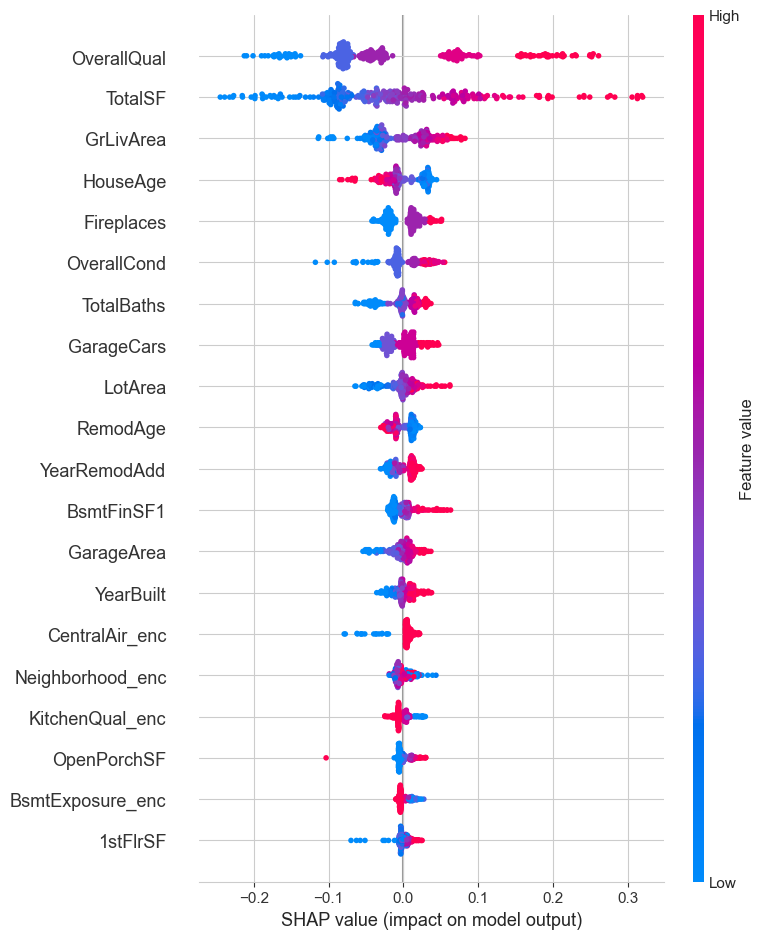

In [65]:
# Use a random sample of 300 test observations for speed
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(len(X_test), size=min(300, len(X_test)), replace=False)
X_shap = X_test[sample_idx]

explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_shap)

shap.summary_plot(
    shap_values, X_shap,
    feature_names=features,
    max_display=20,
    show=True,
)


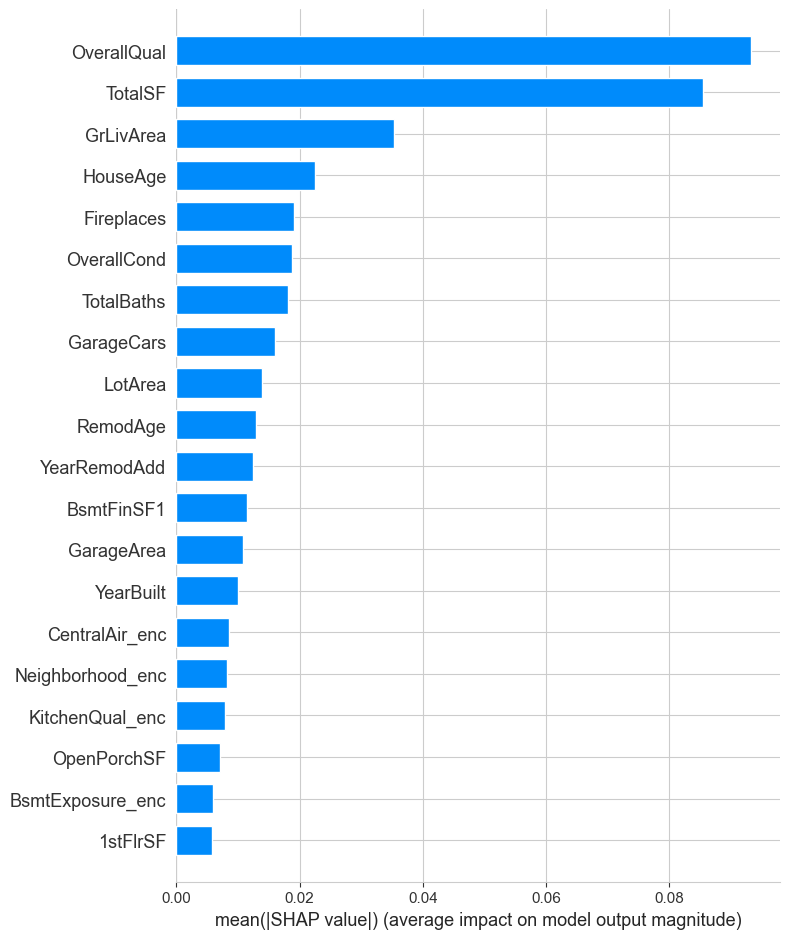

In [66]:
# Bar chart: mean absolute SHAP value per feature
shap.summary_plot(
    shap_values, X_shap,
    feature_names=features,
    plot_type="bar",
    max_display=20,
    show=True,
)


## 9. Stacking Ensemble

Stacking trains diverse base models and combines their predictions with a *meta-learner*.
To prevent data leakage, the meta-learner is trained on **out-of-fold** cross-validation
predictions from the base models — not on in-sample predictions.

We use three LightGBM configurations with different depths as base learners and a Linear
Regression as the meta-learner.


In [67]:
lgbm_configs = {
    "lgbm_shallow": dict(
        boosting_type="gbdt", metric="rmse", objective="regression",
        n_jobs=-1, seed=RANDOM_STATE, num_leaves=300, max_depth=3,
        learning_rate=0.01, bagging_fraction=0.5, colsample_bytree=0.5,
        n_estimators=200, verbose=-1,
    ),
    "lgbm_deep": dict(
        boosting_type="gbdt", metric="rmse", objective="regression",
        n_jobs=-1, seed=RANDOM_STATE, num_leaves=700, max_depth=10,
        learning_rate=0.01, bagging_fraction=0.95, colsample_bytree=0.95,
        n_estimators=200, verbose=-1,
    ),
    "lgbm_medium": dict(
        boosting_type="gbdt", metric="rmse", objective="regression",
        n_jobs=-1, seed=RANDOM_STATE, num_leaves=50, max_depth=5,
        learning_rate=0.01, bagging_fraction=0.5, colsample_bytree=0.5,
        n_estimators=200, verbose=-1,
    ),
}

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
val_preds  = {}
test_preds = {}

for name, params in lgbm_configs.items():
    model = LGBMRegressor(**params)
    cv_pred = cross_val_predict(model, X_train, y_train, cv=kf, n_jobs=-1)
    val_preds[name] = cv_pred

    model.fit(X_train, y_train)
    test_preds[name] = model.predict(X_test)

    cv_r   = root_mean_squared_error(y_train, cv_pred)
    test_r = root_mean_squared_error(y_test, test_preds[name])
    print(f"{name:20s}  CV RMSE={cv_r:.4f}   Test RMSE={test_r:.4f}")


lgbm_shallow          CV RMSE=0.1713   Test RMSE=0.1683
lgbm_deep             CV RMSE=0.1584   Test RMSE=0.1513
lgbm_medium           CV RMSE=0.1590   Test RMSE=0.1529


lgbm_deep             CV RMSE=0.1584   Test RMSE=0.1513


lgbm_medium           CV RMSE=0.1590   Test RMSE=0.1529


In [68]:
# Meta-learner: trained on out-of-fold base-model predictions
val_meta  = np.column_stack([val_preds[n]  for n in lgbm_configs])
test_meta = np.column_stack([test_preds[n] for n in lgbm_configs])

meta = LinearRegression()
meta.fit(val_meta, y_train)

stacking_val_rmse  = root_mean_squared_error(y_train, meta.predict(val_meta))
stacking_test_rmse = root_mean_squared_error(y_test,  meta.predict(test_meta))

print(f"Stacking Train (OOF) RMSE : {stacking_val_rmse:.5f}")
print(f"Stacking Test RMSE        : {stacking_test_rmse:.5f}")
print(f"Meta-learner coefficients : {meta.coef_.round(4)}")


Stacking Train (OOF) RMSE : 0.14075
Stacking Test RMSE        : 0.13092
Meta-learner coefficients : [-0.7395  0.0221  1.9206]


## 10. Conclusions

This notebook covered a complete regression pipeline for residential property price prediction:

| Finding | Detail |
|---------|--------|
| **Best single model** | LightGBM achieves the lowest test RMSE on the log-price scale |
| **Top predictors** | `OverallQual`, `GrLivArea`, `TotalBsmtSF`, `YearBuilt` |
| **Regularisation** | Lasso provides automatic feature selection; Ridge is more stable |
| **Stacking** | Combining diverse LightGBM configurations further reduces error |
| **Residuals** | Errors are approximately normally distributed, confirming model validity |

### Recommendations for Further Improvement
- Impute missing values more carefully (median for numeric, mode for categorical, physical meaning for structural absences)
- Engineer interaction features: `TotalSF = 1stFlrSF + 2ndFlrSF + TotalBsmtSF`
- Apply log-transform to skewed numeric features such as `LotArea` and `GrLivArea`
- Tune hyperparameters with Optuna or Bayesian optimisation
- Add neural networks (TabNet, MLP) for comparison
